📝 Case Study: Customer Support Assistant (Multi-Agent with LangGraph)  
🎯 Goal

Simulate a customer support system with 3 agents:

Router Agent → Understands the query and routes it.

FAQ Agent → Answers product/policy questions.

Escalation Agent → For anything it can’t handle.

In [ ]:
%pip install -qqqq -U langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.1/158.1 kB 2.6 MB/s eta 0:00:00


In [ ]:
from typing import TypedDict

class AgentState(TypedDict):
    query: str
    category: str
    answer: str

In [ ]:
### Define Agents

# Router Agent
def router_agent(state: AgentState) -> AgentState:
    q = state["query"].lower()
    if "refund" in q or "return" in q:
        state["category"] = "faq"
    else:
        state["category"] = "escalate"
    return state

# FAQ Agent
def faq_agent(state: AgentState) -> AgentState:
    faq_db = {
        "refund": "Our refund policy allows returns within 30 days of purchase.",
        "return": "You can return items via our online portal or any store location."
    }
    for k, v in faq_db.items():
        if k in state["query"].lower():
            state["answer"] = v
            return state
    state["answer"] = "Sorry, I don’t know the answer."
    return state

# Escalation Agent
def escalation_agent(state: AgentState) -> AgentState:
    state["answer"] = "This query needs a human support agent. Escalating..."
    return state

In [ ]:
### Build Workflow

from langgraph.graph import StateGraph, END

workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("router", router_agent)
workflow.add_node("faq", faq_agent)
workflow.add_node("escalate", escalation_agent)

# Entry point
workflow.set_entry_point("router")

# Conditional edges - registering handoff
def route_from_router(state: AgentState):
    if state["category"] == "faq":
        return "faq"
    else:
        return "escalate"

workflow.add_conditional_edges("router", route_from_router, {
    "faq": "faq",
    "escalate": "escalate"
})

# Both FAQ and Escalation go to END
workflow.add_edge("faq", END)
workflow.add_edge("escalate", END)

app = workflow.compile()


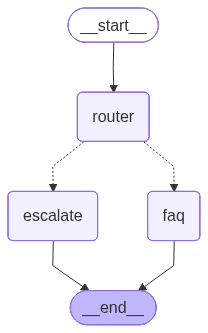

In [ ]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
### Run Demo

queries = [
    "How do I get a refund?",
    "Can I return a product?",
    "What are your store timings?"
]

for q in queries:
    print("\n==============================")
    print("User Query:", q)
    result = app.invoke({"query": q})
    print("Category:", result["category"])
    print("Answer:", result["answer"])



User Query: How do I get a refund?
Category: faq
Answer: Our refund policy allows returns within 30 days of purchase.

User Query: Can I return a product?
Category: faq
Answer: You can return items via our online portal or any store location.

User Query: What are your store timings?
Category: escalate
Answer: This query needs a human support agent. Escalating...


[Optional] - Recreating the same agent with LLM exposure.

In [ ]:
# Add necessary imports for LLM (OpenAI)
from openai import OpenAI
from google.colab import userdata

# Set up OpenAI API key
try:
    OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
    client = OpenAI(api_key=OPENAI_API_KEY)
except userdata.SecretNotFoundError:
    print("OpenAI API key not found. Please add your OPENAI_API_KEY to Colab secrets.")
    client = None

In [ ]:

# Modify FAQ Agent to use LLM (OpenAI)
def faq_agent_with_llm(state: AgentState) -> AgentState:
    if not client:
        state["answer"] = "OpenAI client not initialized. Cannot answer FAQ."
        return state

    faq_db = {
        "refund": "Our refund policy allows returns within 30 days of purchase.",
        "return": "You can return items via our online portal or any store location."
    }
    query = state["query"].lower()
    for k, v in faq_db.items():
        if k in query:
            state["answer"] = v
            return state

    # If not in FAQ DB, use LLM to generate a response
    prompt = f"The user is asking: '{state['query']}'. Based on the following FAQ information:\nRefund: Our refund policy allows returns within 30 days of purchase.\nReturn: You can return items via our online portal or any store location.\n\nIf the question is related to refund or return, answer based on the provided information. Otherwise, state that you cannot answer this question."

    try:
        response = client.chat.completions.create(
            model="gpt-3.5-turbo",  # Using gpt-3.5-turbo as an example
            messages=[
                {"role": "system", "content": "You are a helpful assistant that answers questions based on provided information."},
                {"role": "user", "content": prompt}
            ]
        )
        state["answer"] = response.choices[0].message.content
    except Exception as e:
        state["answer"] = f"Error generating response from OpenAI LLM: {e}"

    return state

# Modify Escalation Agent to use LLM (OpenAI - optional, can keep as is or use LLM for a more detailed escalation message)
def escalation_agent_with_llm(state: AgentState) -> AgentState:
    """ Escalation Agent that handles all escalations """
    if not client:
        state["answer"] = "OpenAI client not initialized. Cannot escalate."
        return state

    prompt = f"""The user is asking: '{state['query']}'. This query needs to be escalated to a human support agent.
    Generate a response that sounds like you escalated to a human and the human responded back with a reasonable answer."""
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini", # Using gpt-3.5-turbo as an example
            messages=[
                {"role": "system", "content": "You are a helpful assistant."},
                {"role": "user", "content": prompt}
            ]
        )
        state["answer"] = response.choices[0].message.content
    except Exception as e:
        state["answer"] = f"Error generating response from OpenAI LLM: {e}"

    return state


In [ ]:
# Rebuild Workflow with modified agents
from langgraph.graph import StateGraph, END

# Conditional edges (remain the same)
def route_from_router(state: AgentState):
    if state["category"] == "faq":
        return "faq"
    else:
        return "escalate"

workflow = StateGraph(AgentState)

# Add nodes with modified agents
workflow.add_node("router", router_agent) # Router remains the same
workflow.add_node("faq", faq_agent_with_llm)
workflow.add_node("escalate", escalation_agent_with_llm)

# Entry point
workflow.set_entry_point("router")

workflow.add_conditional_edges("router", route_from_router, {
    "faq": "faq",
    "escalate": "escalate"
})

# Both FAQ and Escalation go to END
workflow.add_edge("faq", END)
workflow.add_edge("escalate", END)

app_with_llm = workflow.compile()

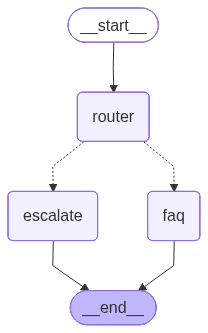

In [ ]:
from IPython.display import Image, display

# Generate and display the graph
graph_image = app_with_llm.get_graph().draw_mermaid_png()
display(Image(graph_image))

In [ ]:
### Run Demo with LLM
queries = [
    "How do I get a refund?",
    "Can I return a product?",
    "What are your store timings?"
]

for q in queries:
    print("\n==============================")
    print("User Query:", q)
    result = app_with_llm.invoke({"query": q})
    print("Category:", result["category"])
    print("Answer:", result["answer"])



User Query: How do I get a refund?
Category: faq
Answer: Our refund policy allows returns within 30 days of purchase.

User Query: Can I return a product?
Category: faq
Answer: You can return items via our online portal or any store location.

User Query: What are your store timings?
Category: escalate
Answer: Thank you for your inquiry about our store timings! I’ve escalated your question to a human support agent, and here’s the response I received:

"Our store timings are as follows:
- Monday to Friday: 9 AM to 8 PM
- Saturday: 10 AM to 6 PM
- Sunday: Closed

If you have any further questions or need assistance, feel free to ask!"
